# 🏠 UrbanNest Analytics — European Housing Intelligence
## Notebook 1: Data Cleaning
**Dataset:** Italian Rental Listings 2016-2020
**Analyst:** Sahil Changotra
**Method:** Simple pandas — clean and readable

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
print("Libraries loaded ✅")

Libraries loaded ✅


## Step 1: Load and Inspect Data

In [40]:
df = pd.read_csv('../data/ha_data_assessement.csv')

In [41]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Shape: (10000, 13)
Rows: 10,000 | Columns: 13


,city,category,country_code,created_at,price,furnished,total_size,registration_possible,washing_machine,tv,balcony,garden,terrace
0,Trento,Shared Room,it,2016-03-12 12:31:31,190.00,"""yes""",NaN,NaN,"""no""","""yes""","""no""","""no""","""no"""
1,Milan,Apartment,it,2019-11-14 14:48:10,3200.00,"""yes""","""50""","""yes""","""yes""","""yes""",NaN,"""no""",NaN
2,Milan,Shared Room,it,2019-10-07 10:08:21,660.00,"""yes""","""180""",NaN,"""yes""",NaN,NaN,NaN,NaN
3,Pisa,Shared Room,it,2017-07-05 11:41:57,245.00,"""yes""","""140""","""no""","""yes""","""no""",NaN,"""no""",NaN
4,Bologna,Private Room,it,2017-11-16 08:55:46,500.00,"""yes""","""18""",NaN,"""yes""","""no""",NaN,NaN,NaN


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   city                   9404 non-null   object 
 1   category               9401 non-null   object 
 2   country_code           10000 non-null  object 
 3   created_at             10000 non-null  object 
 4   price                  10000 non-null  float64
 5   furnished              6803 non-null   object 
 6   total_size             5112 non-null   object 
 7   registration_possible  4977 non-null   object 
 8   washing_machine        7929 non-null   object 
 9   tv                     7031 non-null   object 
 10  balcony                2137 non-null   object 
 11  garden                 6729 non-null   object 
 12  terrace                2086 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1015.8+ KB


In [43]:
df.describe()

,price
count,10000.00
mean,670.43
std,2430.00
min,0.01
25%,285.00
50%,400.00
75%,650.00
max,190205.00


## Step 2: Profile Data Quality
Quick check of NULLs and missing % per column

In [44]:
# Quick data quality profile — one row per column

profile = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count' : df.isnull().sum(),
    'null_pct' : round(df.isnull().sum() * 100/ len(df), 2),
    'unique_values' : df.nunique()
}).sort_values('null_pct', ascending = False)

profile

,dtype,null_count,null_pct,unique_values
terrace,object,7914,79.14,4
balcony,object,7863,78.63,4
registration_possible,object,5023,50.23,3
total_size,object,4888,48.88,181
garden,object,3271,32.71,4
furnished,object,3197,31.97,3
tv,object,2969,29.69,3
washing_machine,object,2071,20.71,3
category,object,599,5.99,4
city,object,596,5.96,30


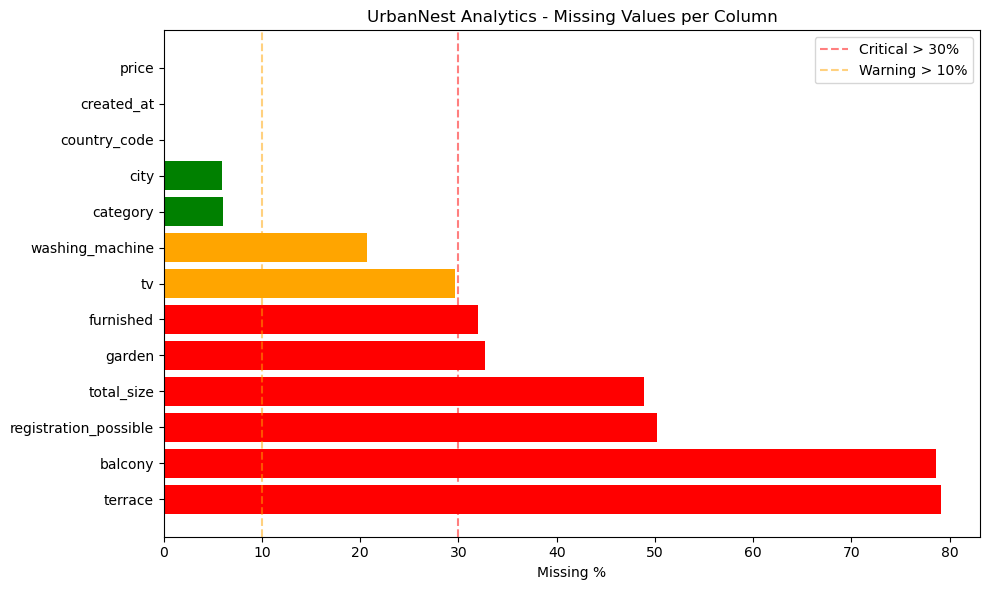

Chart saved ✅


In [48]:
# visualize missing values

plt.figure(figsize=(10,6))
colors = ['red' if x > 30 else 'orange' if x > 10 else 'green'
            for x in profile['null_pct']]
plt.barh(profile.index, profile['null_pct'], color = colors)
plt.axvline(x = 30, color = 'red', linestyle = '--',
            alpha = 0.5, label = 'Critical > 30%')
plt.axvline(x = 10, color = 'orange', linestyle = '--',
            alpha = 0.5, label = 'Warning > 10%')
plt.xlabel('Missing %')
plt.title('UrbanNest Analytics - Missing Values per Column')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/01_missing_values.png', dpi=150)
plt.show()
print("Chart saved ✅")                                    

In [ ]:
# Check what dirty values exist in boolean columns

bool_cols = ['furnished', 'washing_machine','tv','registration_possible','balcony','terrace','garden']
for col in bool_cols:
    print(f"{col}: {df[col].unique()[:6]}")





furnished: ['"yes"' nan '"no"' '""']
washing_machine: ['"no"' '"yes"' nan '""']
tv: ['"yes"' nan '"no"' '""']
registration_possible: [nan '"yes"' '"no"' '""']
balcony: ['"no"' nan '"private"' '"shared"' '""']
terrace: ['"no"' nan '"shared"' '""' '"private"']
garden: ['"no"' nan '"shared"' '"private"' '""']


✅ Triple quotes — """yes""" → need stripping

✅ Empty strings — "" → need converting to NaN

✅ shared/private in balcony/garden/terrace → convert to yes

## Step 3: Fix Data Types + Clean Boolean Columns

In [ ]:
# Fix created_at to datetime

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(f"created_at dtype: {df['created_at'].dtype} ✅")

created_at dtype: datetime64[ns] ✅


In [ ]:
# Clean all Boolean Columns

bool_cols = ['furnished', 'washing_machine','tv','registration_possible','balcony','terrace','garden']

In [ ]:
for col in bool_cols:
    
    # Step 1: strip quotes + whitespace
    df[col] = df[col].astype(str).str.replace('"','',regex=False).str.strip()

    # Step 2: Replace null strings + empty -> NaN
    df[col] = df[col].replace(['nan','null','','NULL'], np.nan)

    # Step 3: shared/ private -> yes
    df[col] = df[col].replace({'shared':'yes','private':'yes'})

    # Step 4: Keep only yes/no/NaN
    df[col] = df[col].apply(
        lambda x: x if pd.isna(x) or x in ['yes','no'] else np.nan
    )

In [ ]:
for col in bool_cols:
    print(df[col].unique())

['yes' nan 'no']
['no' 'yes' nan]
['yes' nan 'no']
[nan 'yes' 'no']
['no' nan 'yes']
['no' nan 'yes']
['no' nan 'yes']


In [ ]:
# Strip quotes → remove non-numeric → convert to float

df['total_size'] = df['total_size'].astype(str)\
                            .str.replace('"','',regex=False)\
                            .str.strip()
df['total_size'] = df['total_size'].replace(
    ['nan','null','','NULL','none'], np.nan
)                               
df['total_size'] = pd.to_numeric(df['total_size'], errors='coerce')

print(f"total_size dtype: {df['total_size'].dtype} ✅")
print(f"Min: {df['total_size'].min()} | Max: {df['total_size'].max()}")

total_size dtype: float64 ✅
Min: -135.0 | Max: 10000.0


## Step 4: Handle NULLs
- Drop rows where city or category is NULL (critical columns)
- Keep NULLs in amenity columns — they mean "not specified"

In [ ]:
# fix city and category empty strings

df['city'] = df['city'].astype(str).str.strip().replace('nan',np.nan)

df['category'] = df['category'].astype(str).str.strip().replace('nan',np.nan)


print(f"Rows before dropping NULLs: {len(df):,}")
df = df.dropna(subset=['city','category']).reset_index(drop=True)
print(f"Rows after dropping NULLs: {len(df):,}")
print(f"Rows removed: {10000 - len(df):,}")

Rows before dropping NULLs: 8,916
Rows after dropping NULLs: 8,916
Rows removed: 1,084


## Step 5: Handle Duplicates
Identify and remove duplicate listings
keeping first occurrence

In [ ]:
# Find + Remove duplicates

dupes = df.duplicated(subset=['city','category','created_at','price'])

print(f"Duplicate rows found: {dupes.sum()}")

df = df.drop_duplicates(subset=['city','category','created_at','price'],
                        keep = 'first').reset_index(drop=True)

print(f"Rows after dedup: {len(df):,}") 

Duplicate rows found: 4
Rows after dedup: 8,912


## Step 6: Handle Outliers
- Price outliers using IQR method
- Business logic floor: price >= £10
- total_size: remove impossible values

In [ ]:
# Price Outlier Analysis

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Upper fence: £{upper_fence:.2f}")
print(f"Price < £10: {(df['price'] < 10).sum()}")
print(f"Above fence: {(df['price'] > upper_fence).sum()}")

Q1: £285.00
Q3: £640.00
IQR: £355.00
Upper fence: £1172.50
Price < £10: 38
Above fence: 1185


In [ ]:
# Flag + Remove price Errors

df['is_price_outlier'] = df['price'] > upper_fence

print(f"Total rows:        {len(df):,}")
print(f"Normal listings:   {(~df['is_price_outlier']).sum():,}")
print(f"Flagged outliers:  {df['is_price_outlier'].sum():,}")
print(f"Normal %:          {round((~df['is_price_outlier']).sum() * 100 / len(df), 1)}%")
print(f"Outlier %:         {round(df['is_price_outlier'].sum() * 100 / len(df), 1)}%")

Total rows:        8,874
Normal listings:   7,689
Flagged outliers:  1,185
Normal %:          86.6%
Outlier %:         13.4%


In [ ]:
# fix total_size outliers

df.loc[df['total_size'] <= 0, 'total_size'] = np.nan
df.loc[df['total_size'] > 1000, 'total_size'] = np.nan

print(f"total_size min: {df['total_size'].min()}")
print(f"total_size max: {df['total_size'].max()}")
print(f"total_size NaN: {df['total_size'].isnull().sum():,}")

total_size min: 1.0
total_size max: 800.0
total_size NaN: 4,682


## Step 7: Validate Cleaned Data + Export
Final checks before exporting clean dataset

In [ ]:
print('=' * 45)
print('FINAL VALIDATION')
print('=' * 45)

# Critical NULLs

print("\n--- Critical columns ---")
for col in ['city','category','price','created_at']:
    nulls = df[col].isnull().sum()
    status = "✅" if nulls == 0 else "⚠️"
    print(f"{status}{col}: {nulls} NULLs")

# price range

print("\n--- Price range ---")
print(f"✅ Min: £{df['price'].min():.2f}")
print(f"✅ Max: £{df['price'].max():.2f}")
print(f"✅ Median: £{df['price'].median():.2f}")

# Boolean columns

print("\n--- Boolean columns---")
for col in ['furnished', 'washing_machine', 'tv',
            'balcony', 'garden', 'terrace',
            'registration_possible']:
            vals = df[col].dropna().unique().tolist()
            status = "✅" if all(v in ['yes','no'] for v in vals) else "⚠️"
            print(f"{status} {col}: {vals}")

# Category distribution
print("\n--- Category split ---")
print(df['category'].value_counts())

# City distribution
print("\n--- Top 10 cities ---")
print(df['city'].value_counts().head(10))

FINAL VALIDATION

--- Critical columns ---
✅city: 0 NULLs
✅category: 0 NULLs
✅price: 0 NULLs
✅created_at: 0 NULLs

--- Price range ---
✅ Min: £10.00
✅ Max: £100000.00
✅ Median: £400.00

--- Boolean columns---
✅ furnished: ['yes', 'no']
✅ washing_machine: ['no', 'yes']
✅ tv: ['yes', 'no']
✅ balcony: ['no']
✅ garden: ['no']
✅ terrace: ['no']
✅ registration_possible: ['yes', 'no']

--- Category split ---
category
Private Room    5196
Shared Room     1596
Apartment       1552
Studio           530
Name: count, dtype: int64

--- Top 10 cities ---
city
Milan       2063
Bologna     1694
Pisa        1451
Florence    1240
Turin        596
Rome         545
Trento       228
Siena        177
Padova       114
Trieste      101
Name: count, dtype: int64


In [ ]:
# Cleaning Summary

print("=" * 50)
print("URBANNEST ANALYTICS — CLEANING SUMMARY")
print("=" * 50)
print(f"Original rows:          10,000")
print(f"After NULL drops:        8,916")
print(f"After dedup:             8,912")
print(f"After price < £10:       {len(df):,}")
print(f"Data retention rate:     {round(len(df)/10000*100,1)}%")
print()
print("Fixes applied:")
print("  ✅ created_at → datetime64")
print("  ✅ total_size → float64")
print("  ✅ Triple quotes stripped from boolean columns")
print("  ✅ shared/private → yes in outdoor columns")
print("  ✅ null strings → NaN")
print("  ✅ Duplicates removed")
print("  ✅ Price < £10 removed")
print("  ✅ total_size > 1000 sqm → NaN")
print("  ✅ is_price_outlier flag added")

URBANNEST ANALYTICS — CLEANING SUMMARY
Original rows:          10,000
After NULL drops:        8,916
After dedup:             8,912
After price < £10:       8,874
Data retention rate:     88.7%

Fixes applied:
  ✅ created_at → datetime64
  ✅ total_size → float64
  ✅ Triple quotes stripped from boolean columns
  ✅ shared/private → yes in outdoor columns
  ✅ null strings → NaN
  ✅ Duplicates removed
  ✅ Price < £10 removed
  ✅ total_size > 1000 sqm → NaN
  ✅ is_price_outlier flag added


In [ ]:
# Export clean dataset

df.to_csv('../data/ha_data_clean.csv', index=False)
print(f"✅ Clean dataset exported!")
print(f"   Rows:    {len(df):,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Path:    data/ha_data_clean.csv")

✅ Clean dataset exported!
   Rows:    8,874
   Columns: 14
   Path:    data/ha_data_clean.csv
